### About the Project

This project builds 3 simple deep neural network models to perform image classification on the CIFAR-10 data set, wherein each subsequent model is an attempt to improve upon predecessing models by modifying them in several ways. The aim is to learn some basics of DNN and how different training hyperparameters affect performance.

In [ ]:
import numpy as np
import tensorflow as tf
import keras         
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense, GlobalAveragePooling2D


2026-01-10 17:50:35.932472: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-10 17:50:36.250497: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# PLEASE DO NOT CHANGE THIS CODE

# Load the cifar10 dataset and split train/test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Split train/valid from the training set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=5)

print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Validation shape: X_val = " + str(X_val.shape) + ", y_val = " + str(y_val.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train shape: X_train = (45000, 32, 32, 3), y_train = (45000, 1)
Validation shape: X_val = (5000, 32, 32, 3), y_val = (5000, 1)
Test shape: X_test = (10000, 32, 32, 3), y_test = (10000, 1)


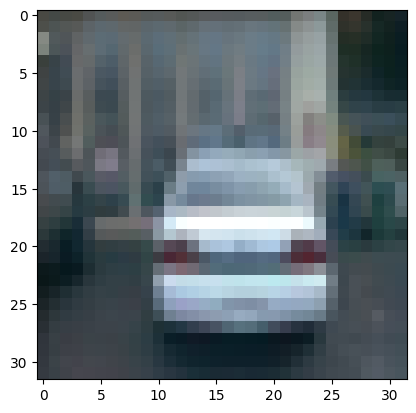

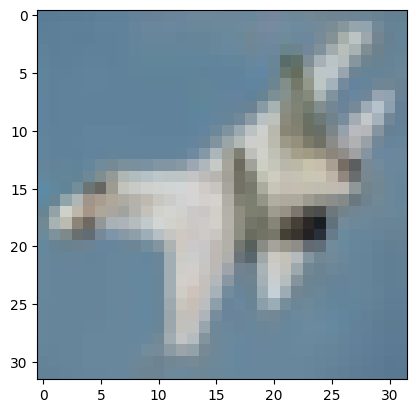

In [5]:
# Show some samples in the dataset
import matplotlib.pyplot as plt
imgplot = plt.imshow(X_train[5])
plt.show()
imgplot = plt.imshow(X_test[10])
plt.show()

1.  **(5 points) Coding tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Load the CIFAR-10 dataset, visualize sample images, and perform data normalization to improve training performance.  
    1.2 *(1 point)* First network: Build, train, and test a deep neural network with at least three convolutional layers, two fully connected layers, and two pooling layers.  
    1.3 *(1 point)* Second network: Build, train, and test another deep neural network, with an architecture of your choice, but at most 4M (four million) parameters, ensuring the architecture meets this constraint by verifying with model.summary().  
    1.4 *(2 points)* Modify the second network architecture by tuning the layer hyperparameters or adjusting the layer design to improve test accuracy while remaining within the four million parameter limit. Discuss your observations and the trade offs of the changes you make.  

Label: [0]
Pixel values: [[[160 150 130]
  [141 132 105]
  [101 100  69]
  ...
  [137 143 118]
  [108 109  78]
  [ 78  78  43]]

 [[167 160 142]
  [147 142 114]
  [101 104  71]
  ...
  [134 140 114]
  [106 107  76]
  [ 80  79  44]]

 [[167 162 144]
  [149 143 117]
  [104 105  73]
  ...
  [131 133 107]
  [102 104  73]
  [ 79  83  48]]

 ...

 [[ 78  79  41]
  [ 87  82  44]
  [ 82  74  43]
  ...
  [152 124  88]
  [126 114  69]
  [134 130  78]]

 [[ 87  87  46]
  [ 94  87  49]
  [ 88  79  47]
  ...
  [155 118  84]
  [159 140  94]
  [149 142  89]]

 [[ 90  88  47]
  [ 97  88  49]
  [ 90  82  47]
  ...
  [130  93  60]
  [167 135  99]
  [180 156 115]]]


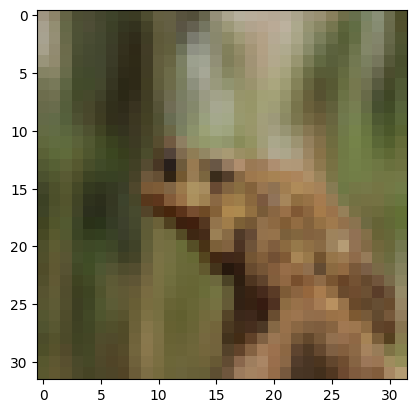

In [ ]:
# Show label and pixel values of an image
print("Label:", y_train[0])
print("Pixel values:", X_train[2])

# Show the image
imgplot = plt.imshow(X_train[2])
plt.show()

In [ ]:
X_train_norm, X_val_norm, X_test_norm = X_train/255.0, X_val/255.0, X_test/255.0

In [ ]:
dnn_model = Sequential()

# 1st Conv Block
dnn_model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
dnn_model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
dnn_model.add(MaxPooling2D((2,2)))
dnn_model.add(Dropout(0.3))


# 2nd Conv Block
dnn_model.add(Conv2D(64, (4,3), activation='relu', padding='same'))
dnn_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
dnn_model.add(MaxPooling2D((2,2)))

# 3rd Conv Block
dnn_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))

# Flatten
dnn_model.add(Flatten())
# Fully Connected Block
dnn_model.add(Dense(150, activation='relu'))
dnn_model.add(Dropout(0.3))
dnn_model.add(Dense(75, activation='relu'))

# Output
dnn_model.add(Dense(10, activation='softmax'))

# dnn_model = Sequential() # Initialize a sequential model.
# dnn_model.add(Conv2D(filters=32, input_shape=(32, 32, 3), kernel_size=(3,3), activation='relu', padding='same')) # Add 2D Convolutional layer
# dnn_model.add(MaxPooling2D((2, 2))) # Add Max Pooling layer
# dnn_model.add(Flatten()) # Flatten the vector to 1D
# dnn_model.add(Dense(100, activation='relu')) # Add FC layer and Relu activation
# dnn_model.add(Dense(10, activation='softmax')) # Add FC layer and Softmax activation for classification

dnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1765282970.722514      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │     1,228,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,386,603 (5.29 MB)

 Trainable params: 1,386,603 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Compile the model
dnn_model.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # loss function
                optimizer= tf.keras.optimizers.Adam(learning_rate=1e-3), metrics=['accuracy']) #initial learning rate and metrics.

history = dnn_model.fit(X_train_norm, y_train, 
                    batch_size=500, 
                    epochs=25,
                    validation_data=(X_val_norm, y_val)) 

Epoch 1/25


I0000 00:00:1765282975.976540     109 service.cc:148] XLA service 0x7e2df8002b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765282975.977281     109 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765282976.363368     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


 7/90 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1026 - loss: 2.3019

I0000 00:00:1765282981.151600     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.2126 - loss: 2.0953 - val_accuracy: 0.4044 - val_loss: 1.6086
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4161 - loss: 1.5829 - val_accuracy: 0.5048 - val_loss: 1.3827
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5109 - loss: 1.3527 - val_accuracy: 0.5068 - val_loss: 1.3877
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5594 - loss: 1.2264 - val_accuracy: 0.5900 - val_loss: 1.1266
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5998 - loss: 1.1263 - val_accuracy: 0.6370 - val_loss: 1.0241
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6379 - loss: 1.0192 - val_accuracy: 0.6646 - val_loss: 0.9436
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6675 - loss: 0.9372 - val_accuracy: 0.6830 - val_loss: 0.8955
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6959 - loss: 0.8581 - val_accuracy: 0.6970 - val_loss: 0

In [ ]:
# Show the model performance
result = dnn_model.evaluate(X_test_norm, y_test)
print(dnn_model.metrics_names) 
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7720 - loss: 0.8593
['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 0.863778293132782, accuracy = 0.771399974822998


In [ ]:
dnn_model_2 = Sequential()

# 1st Conv Block
dnn_model_2.add(Conv2D(64, (3,3), activation='relu', padding='same',
                       input_shape=(32,32,3)))
dnn_model_2.add(Conv2D(64, (3,3), activation='relu', padding='same'))
dnn_model_2.add(MaxPooling2D((2,2)))
# dnn_model_2.add(Dropout(0.3))

# 2nd Conv Block
dnn_model_2.add(Conv2D(128, (3,3), activation='relu', padding='same'))
dnn_model_2.add(Conv2D(128, (3,3), activation='relu', padding='same'))
dnn_model_2.add(MaxPooling2D((2,2)))

# 3rd Conv Block
dnn_model_2.add(Conv2D(256, (3,3), activation='relu', padding='same'))
dnn_model_2.add(Conv2D(256, (3,3), activation='relu', padding='same'))
dnn_model_2.add(MaxPooling2D((2,2)))
dnn_model_2.add(Dropout(0.3))

# Flatten
dnn_model_2.add(Flatten())

# Fully Connected Block
dnn_model_2.add(Dense(512, activation='relu'))
dnn_model_2.add(Dropout(0.5))
dnn_model_2.add(Dense(256, activation='relu'))
dnn_model_2.add(Dropout(0.5))
# dnn_model_2.add(Dense(256, activation='relu'))
# dnn_model_2.add(Dropout(0.5))
# dnn_model_2.add(Dense(128, activation='relu'))
# dnn_model_2.add(Dropout(0.5))


# Output
dnn_model_2.add(Dense(10, activation='softmax'))

# Output
dnn_model_2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,376,970 (12.88 MB)

 Trainable params: 3,376,970 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dnn_model_2.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Define loss function
                optimizer= tf.keras.optimizers.Adam(learning_rate=1e-3), metrics=['accuracy']) # Define initial learning rate and metrics.

history_2 = dnn_model_2.fit(X_train_norm, y_train,
                    batch_size=64, 
                    epochs=25, 
                    validation_data=(X_val_norm, y_val)) 

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.2333 - loss: 1.9924 - val_accuracy: 0.4736 - val_loss: 1.4380
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5078 - loss: 1.3578 - val_accuracy: 0.5722 - val_loss: 1.2102
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6109 - loss: 1.0969 - val_accuracy: 0.6438 - val_loss: 0.9902
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6721 - loss: 0.9384 - val_accuracy: 0.6830 - val_loss: 0.8812
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7159 - loss: 0.8325 - val_accuracy: 0.7106 - val_loss: 0.8187
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7432 - loss: 0.7380 - val_accuracy: 0.7198 - val_loss: 0.7950
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7715 - loss: 0.6665 - val_accuracy: 0.7378 - val_loss: 0.7623
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7867 - loss: 0.6204 - val_acc

In [ ]:
result_2 = dnn_model_2.evaluate(X_test_norm, y_test) 
print(dnn_model_2.metrics_names)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result_2[0],result_2[1]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7799 - loss: 0.7378
['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 0.750247597694397, accuracy = 0.7817000150680542


In [ ]:
'''
I changed flatten to global average pooling, added image augmentation and batch normalization, the model was then trained with learning rate scheduling.
Accuracy was improved (hypothetically) due to better generalizability of the model.
'''
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    # tf.keras.layers.RandomContrast(0.1), # vary contrast by at most 10%
    # tf.keras.layers.RandomBrightness(0.03) # vary brightness by at most 10%
], name="data_augmentation")

dnn_model_3 = Sequential()
dnn_model_3.add(data_augmentation)

# 1st Conv Block
dnn_model_3.add(Conv2D(64, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(Conv2D(64, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(MaxPooling2D((2,2)))


# 2nd Conv Block
dnn_model_3.add(Conv2D(128, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(Conv2D(128, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(MaxPooling2D((2,2)))

# 3rd Conv Block
dnn_model_3.add(Conv2D(256, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(Conv2D(256, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(MaxPooling2D((2,2)))
dnn_model_3.add(Dropout(0.3))

# 3rd Conv Block
dnn_model_3.add(Conv2D(512, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(Conv2D(512, (3,3), padding='same'))
dnn_model_3.add(BatchNormalization())
dnn_model_3.add(Activation('relu'))

dnn_model_3.add(MaxPooling2D((2,2)))
dnn_model_3.add(Dropout(0.3))

# Flatten
dnn_model_3.add(GlobalAveragePooling2D())

# Fully Connected Block
dnn_model_3.add(Dense(1024, activation='relu'))
dnn_model_3.add(Dropout(0.5))
dnn_model_3.add(Dense(512, activation='relu'))
dnn_model_3.add(Dropout(0.5))
# Output
dnn_model_3.add(Dense(10, activation='softmax'))

# Compile the model
dnn_model_3.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Define loss function
                optimizer= tf.keras.optimizers.Adam(learning_rate=1e-3),
                    metrics=['accuracy']) # Define initial learning rate and metrics.



# Output
dnn_model_3.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 4, 4, 256)      │             

 Total params: 5,748,298 (21.93 MB)

 Trainable params: 5,744,458 (21.91 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
from keras.callbacks import ReduceLROnPlateau
lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history_3 = dnn_model_3.fit(X_train_norm, y_train, 
                    batch_size=64, 
                    epochs=50, 
                    validation_data=(X_val_norm, y_val),
                    callbacks=[lr_schedule]) 

Epoch 1/50


E0000 00:00:1765284753.618222      47 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_9_1/dropout_26_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.2886 - loss: 1.9081 - val_accuracy: 0.4228 - val_loss: 1.5670 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4777 - loss: 1.4498 - val_accuracy: 0.3138 - val_loss: 3.0576 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5526 - loss: 1.2622 - val_accuracy: 0.5490 - val_loss: 1.4445 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6004 - loss: 1.1420 - val_accuracy: 0.3576 - val_loss: 2.8292 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6305 - loss: 1.0611 - val_accuracy: 0.5656 - val_loss: 1.4850 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6696 - loss: 0.9680 - val_accuracy: 0.6442 - val_loss: 0.9896 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6866 - loss: 0.9247

In [28]:
result_3 = dnn_model_3.evaluate(X_test_norm, y_test) # If unspecified, batch_size will default to 32
print(dnn_model_3.metrics_names) # result[0] is loss, result[1] is accuracy. The metrics are defined in dnn_model.complie(...)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result_3[0],result_3[1]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8649 - loss: 0.4331
['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 0.4270082414150238, accuracy = 0.863099992275238


#### Personal Observations 
During training, hyperparameter tuning affect the model in several ways:
- Learning rate: higher learning rate slowers training but yielded higher accuracy.
- Batch size: I found that lowering the batch size to 32 - 128 helped the model generalize a bit better, the first times i
ran the model at >1000 batch sizes it seemed training accuracy was increasing but val accuracy plateaued
- Drop out: drop out helped prevent overfitting making the model generalize better. However it also lowered accuracy when ussed 
excessively
